In [10]:
# %pip install kilonova-source

import skysurvey
import numpy as np
from kilonova_source import KilonovaSource 

np.random.seed(2017)

In [11]:
KNe = KilonovaSource('./Bu2025_raw_data.h5')

KeyError: 'Unable to synchronously open object (component not found)'

In [9]:
print(KNe())

TypeError: KilonovaSource.__init__() missing 1 required positional argument: 'filepath'

In [ ]:
custom_source = 

In [2]:
snia = skysurvey.SNeIa.from_draw(1_000, 
                                 zmax=0.3,
                                 tstart=58_000, tstop=58_200,
                                 radec={"ra_range":[100, 200], "dec_range":[-20,30]}, )
snia.model

{'redshift': {'func': 'draw_redshift',
              'kwargs': {'zmax': 0.3, 'rate': 23500.0, 'zmin': 0},
              'as': 'z'},
 'x1': {'func': <function SNeIaStretch.nicolas2021 at 0x7fd1c36a8680>,
        'kwargs': {}},
 'c': {'func': <function SNeIaColor.intrinsic_and_dust at 0x7fd1c36a85e0>,
       'kwargs': {}},
 't0': {'func': <built-in method uniform of numpy.random.mtrand.RandomState object at 0x7fd1f468cc40>,
        'kwargs': {'low': 58000, 'high': 58200}},
 'magabs': {'func': <function SNeIaMagnitude.tripp1998 at 0x7fd1c36a8720>,
            'kwargs': {'x1': '@x1', 'c': '@c', 'mabs': -19.3, 'sigmaint': 0.1}},
 'magobs': {'func': 'magabs_to_magobs',
            'kwargs': {'z': '@z', 'magabs': '@magabs'}},
 'x0': {'func': 'magobs_to_amplitude',
        'kwargs': {'magobs': '@magobs', 'param_name': 'x0'}},
 'radec': {'func': <function random_radec at 0x7fd1c36a60c0>,
           'kwargs': {'ra_range': [100, 200], 'dec_range': [-20, 30]},
           'as': ['ra', 'dec']}}

In [3]:
# footprint
from shapely import geometry
footprint = geometry.Point(0,0).buffer(2) # circle centered on 0,0 with radius of 2

# Observing
import numpy as np
from skysurvey.tools import random_radec

npointings = 50_000
mjd_range = [snia.data["t0"].min()-10, snia.data["t0"].max()+20]

data = {}
data["mjd"] = np.random.uniform(*mjd_range, size=npointings)
data["ra"], data["dec"] = random_radec(ra_range=[100,200], dec_range=[-20, 30], size=npointings)
data["skynoise"] = np.random.normal(loc=350, scale=20, size=npointings)
data["gain"] = 2
data["zp"] = 30
data["band"] = np.random.choice(["desg","desr","desi"], size=npointings)

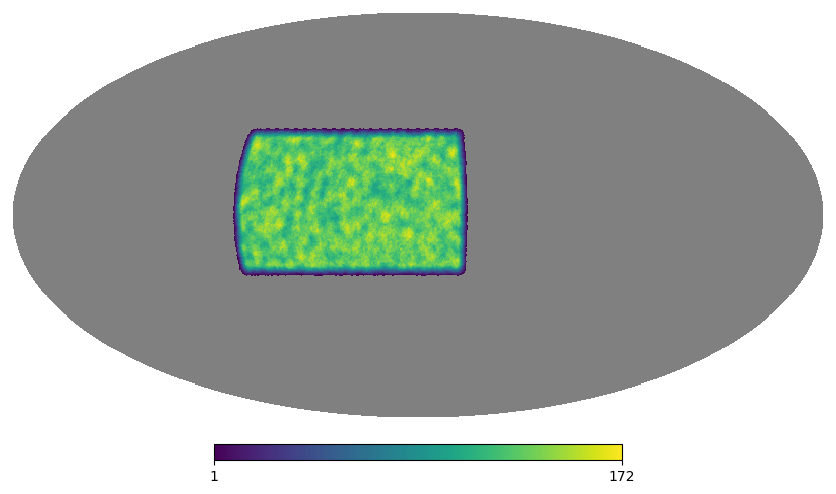

In [4]:
mysurvey = skysurvey.Survey.from_pointings(data, footprint=footprint)
mysurvey.show()

In [5]:
mysurvey.data

,mjd,ra,dec,skynoise,gain,zp,band,fieldid_survey,fieldid
156549,57990.21875,112.542763,26.992775,359.83078,2,30,desr,23925,123749
156690,57990.21875,112.542763,26.992775,359.83078,2,30,desr,23925,123750
156750,57990.21875,112.542763,26.992775,359.83078,2,30,desr,23925,123751
181580,57990.21875,112.542763,26.992775,359.83078,2,30,desr,23925,124547
181690,57990.21875,112.542763,26.992775,359.83078,2,30,desr,23925,124548
...,...,...,...,...,...,...,...,...,...
6232032,58219.984375,136.701538,-11.01655,385.613983,2,30,desg,14210,292497
6232156,58219.984375,136.701538,-11.01655,385.613983,2,30,desg,14210,292498
6260908,58219.984375,136.701538,-11.01655,385.613983,2,30,desg,14210,293295
6261040,58219.984375,136.701538,-11.01655,385.613983,2,30,desg,14210,293296


/home/tbarna/anaconda3/envs/skysurvey/lib/python3.11/site-packages/skysurvey/dataset.py:680: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  this_survey = gsurvey_indexed.get_group(index_).copy()
/home/tbarna/anaconda3/envs/skysurvey/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 500 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


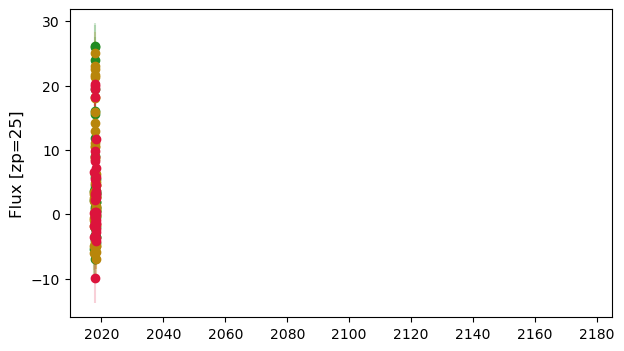

In [6]:
dset = skysurvey.DataSet.from_targets_and_survey(snia, mysurvey)
fig = dset.show_target_lightcurve(index=4, phase_window=[-50, 200])